In [ ]:
import os
import gc
import random
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# Config
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_CLASSES = 102
IMG_SIZE = 224
BATCH_SIZE = 8

NUM_PARALLEL_CALLS = 2
PREFETCH_SIZE = 1

HEAD_EPOCHS = 25
FINETUNE_EPOCHS = 15

MODEL_PATH = "/content/drive/MyDrive/PSI5790/best_flowers102_efficientnetv2b0.weights.h5"

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth:", e)

try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Using mixed precision.")
except Exception as e:
    print("Mixed precision disabled:", e)


# ============================================================
# Dataset
# ============================================================

(ds_train, ds_val, ds_test), info = tfds.load(
    "oxford_flowers102",
    split=["train", "validation", "test"],
    as_supervised=True,
    with_info=True,
)

# Use train + validation as training pool.
# This gives 2040 images instead of only 1020.
ds_train_full = ds_train.concatenate(ds_val)

N_FULL = tf.data.experimental.cardinality(ds_train_full).numpy()
N_INTERNAL_VAL = int(0.15 * N_FULL)

ds_train_full = ds_train_full.shuffle(
    buffer_size=512,
    seed=SEED,
    reshuffle_each_iteration=False,
)

ds_internal_val = ds_train_full.take(N_INTERNAL_VAL)
ds_internal_train = ds_train_full.skip(N_INTERNAL_VAL)

print("Internal train:", tf.data.experimental.cardinality(ds_internal_train).numpy())
print("Internal val:", tf.data.experimental.cardinality(ds_internal_val).numpy())
print("Official test:", tf.data.experimental.cardinality(ds_test).numpy())


# ============================================================
# Preprocess
# ============================================================

def preprocess(image, label):
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # EfficientNetV2 preprocess_input expects 0..255.
    # Do not divide by 255.
    label = tf.one_hot(label, NUM_CLASSES)

    return image, label


train_ds = (
    ds_internal_train
    .shuffle(512, seed=SEED, reshuffle_each_iteration=True)
    .map(preprocess, num_parallel_calls=NUM_PARALLEL_CALLS)
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_SIZE)
)

val_ds = (
    ds_internal_val
    .map(preprocess, num_parallel_calls=NUM_PARALLEL_CALLS)
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_SIZE)
)

test_ds = (
    ds_test
    .map(preprocess, num_parallel_calls=NUM_PARALLEL_CALLS)
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_SIZE)
)


# ============================================================
# Stronger augmentation
# ============================================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.20),
        layers.RandomTranslation(0.10, 0.10),
        layers.RandomContrast(0.20),
        layers.RandomBrightness(0.15),
    ],
    name="data_augmentation",
)


# ============================================================
# Model
# ============================================================

def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg",
    )

    base_model.trainable = False

    x = base_model.output

    # Stronger regularization
    x = layers.Dropout(0.55)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        dtype="float32",
        kernel_regularizer=keras.regularizers.l2(5e-4),
    )(x)

    model = keras.Model(inputs, outputs)

    return model, base_model


model, base_model = build_model()

model.summary()


# ============================================================
# Loss
# ============================================================

loss = keras.losses.CategoricalCrossentropy(
    label_smoothing=0.10
)


# ============================================================
# Phase 1: train only classifier head
# ============================================================

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=5e-4,
        weight_decay=5e-4,
    ),
    loss=loss,
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy"),
    ],
)

callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_head,
)

gc.collect()


# ============================================================
# Phase 2: very light fine-tuning
# ============================================================

model.load_weights(MODEL_PATH)

print("Backbone:", base_model.name)

base_model.trainable = True

# Fine-tune only the last 5% of layers
fine_tune_at = int(len(base_model.layers) * 0.95)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Keep BatchNorm frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=5e-6,
        weight_decay=1e-4,
    ),
    loss=loss,
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy"),
    ],
)

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks_ft,
)

gc.collect()


# ============================================================
# Final evaluation
# ============================================================

model.load_weights(MODEL_PATH)

results = model.evaluate(test_ds, verbose=1)

print("\nFinal test results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.5f}")

Using mixed precision.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c

 Total params: 6,049,974 (23.08 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0284 - loss: 4.8282 - top5_accuracy: 0.0914
Epoch 1: val_accuracy improved from None to 0.32680, saving model to /content/drive/MyDrive/PSI5790/best_flowers102_efficientnetv2b0.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/PSI5790/best_flowers102_efficientnetv2b0.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 56s 124ms/step - accuracy: 0.0623 - loss: 4.6053 - top5_accuracy: 0.1736 - val_accuracy: 0.3268 - val_loss: 3.8462 - val_top5_accuracy: 0.6503 - learning_rate: 5.0000e-04
Epoch 2/25
216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2201 - loss: 3.8273 - top5_accuracy: 0.4828
Epoch 2: val_accuracy improved from 0.32680 to 0.51961, saving model to /content/drive/MyDrive/PSI5790/best_flowers102_efficientnetv2b0.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/PSI5790/best_flowers102_efficientnetv2b0.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.2687 - los

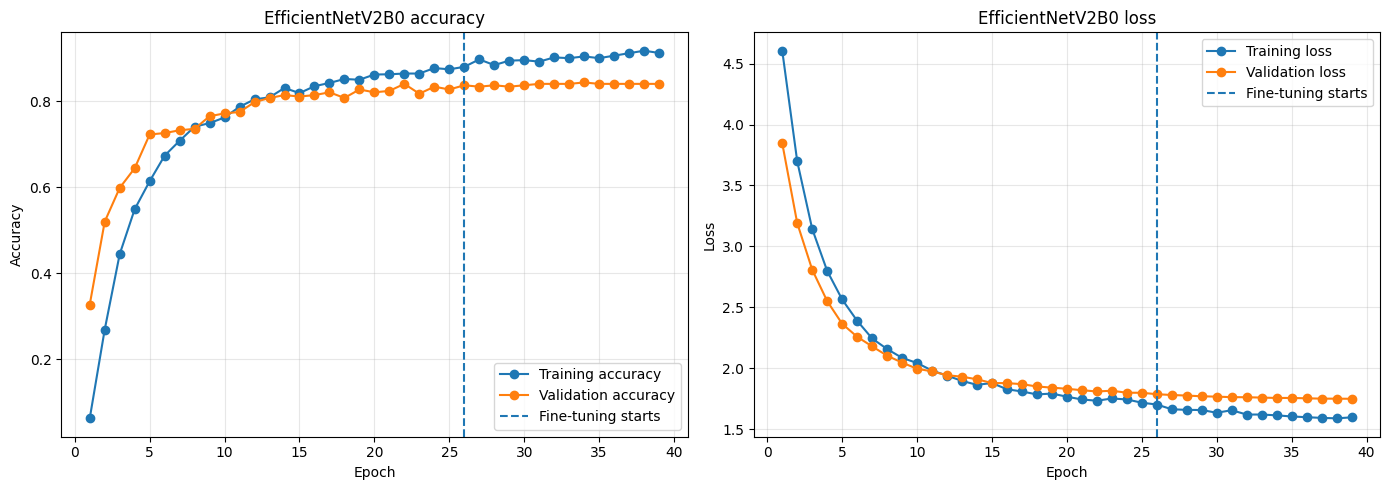

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combine history from phase 1 and fine-tuning phase
acc = history_head.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_ft.history["val_accuracy"]

loss = history_head.history["loss"] + history_ft.history["loss"]
val_loss = history_head.history["val_loss"] + history_ft.history["val_loss"]

epochs = np.arange(1, len(acc) + 1)

# Fine-tuning starts after phase 1
ft_start_epoch = len(history_head.history["accuracy"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs, acc, marker="o", label="Training accuracy")
axes[0].plot(epochs, val_acc, marker="o", label="Validation accuracy")
axes[0].axvline(
    ft_start_epoch,
    linestyle="--",
    label="Fine-tuning starts"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("EfficientNetV2B0 accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs, loss, marker="o", label="Training loss")
axes[1].plot(epochs, val_loss, marker="o", label="Validation loss")
axes[1].axvline(
    ft_start_epoch,
    linestyle="--",
    label="Fine-tuning starts"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("EfficientNetV2B0 loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()